# Hydrogen financial-metric summary

Compare deterministic and aligned Monte Carlo results for all six stand-alone hydrogen routes and both NG-SMR retrofits using NPV, levelized profit margin, or LCOH (the hydrogen LCOX). The paired bar charts share one scale for the selected metric. The retrofit routes resolve against NG-SMR. Figures and tables display inline; this notebook does not save files.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from hydrogen.hydrogen_npv_deterministic import calculate_deterministic_hydrogen_results
from hydrogen.hydrogen_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_hydrogen_results,
)
from hydrogen.hydrogen_financial_summary import (
    HYDROGEN_FINANCIAL_METRIC_OPTIONS,
    HYDROGEN_TECHNOLOGY_LABELS,
    calculate_hydrogen_npv_rankings_from_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import (
    plot_average_rank_bars,
    plot_financial_metric_technology_bars,
    shared_financial_metric_bar_axis_config,
)


## Settings

In [2]:
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE
TECHNOLOGIES = tuple(HYDROGEN_TECHNOLOGY_LABELS)
FINANCIAL_METRIC = "LPM"  # "NPV", "LPM", or "LCOX"

if FINANCIAL_METRIC not in HYDROGEN_FINANCIAL_METRIC_OPTIONS:
    raise ValueError(f"Unknown FINANCIAL_METRIC: {FINANCIAL_METRIC!r}")

METRIC_CONFIG = HYDROGEN_FINANCIAL_METRIC_OPTIONS[FINANCIAL_METRIC]
METRIC_COLUMN = str(METRIC_CONFIG["metric_column"])
METRIC_SCALE_FACTOR = float(METRIC_CONFIG["scale"])
METRIC_SUMMARY_COLUMN = str(METRIC_CONFIG["summary_column"])
METRIC_AXIS_LABEL = str(METRIC_CONFIG["axis_label"])
METRIC_RANKING_LABEL = str(METRIC_CONFIG["ranking_label"])
METRIC_HIGHER_IS_BETTER = bool(METRIC_CONFIG["higher_is_better"])
METRIC_COLOR_BY_SIGN = bool(METRIC_CONFIG["color_by_sign"])
METRIC_ZERO_BASELINE = bool(METRIC_CONFIG["zero_baseline"])
METRIC_AXIS_TICK_STEP = METRIC_CONFIG.get("axis_tick_step")

pd.options.display.float_format = "{:,.3f}".format


## Monte Carlo financial-metric distribution

,label,technology_type,levelized_profit_margin_eur_per_th2,median,p05,p95,non_negative_count,negative_count,non_negative_share
3,SOEC,absolute,"1,674.091","1,672.679",-29.261,"3,380.053",94557,5443,0.946
5,Biomass gasification,absolute,499.833,521.430,20.454,908.013,95676,4324,0.957
1,AEL,absolute,408.774,406.862,"-1,677.865","2,490.925",60677,39323,0.607
2,PEM,absolute,114.859,111.636,"-1,944.367","2,175.273",52929,47071,0.529
7,NG-SMR + CCS,retrofit,81.425,154.278,"-1,174.535","1,092.010",57847,42153,0.578
0,NG-SMR,absolute,33.065,99.261,"-1,088.397",936.020,55630,44370,0.556
6,Biomethane SMR,retrofit,"-1,365.645","-1,363.770","-1,406.894","-1,329.883",0,100000,0.000
4,Methane pyrolysis (TCD),absolute,"-1,555.186","-1,478.395","-3,191.996",-186.357,2350,97650,0.024


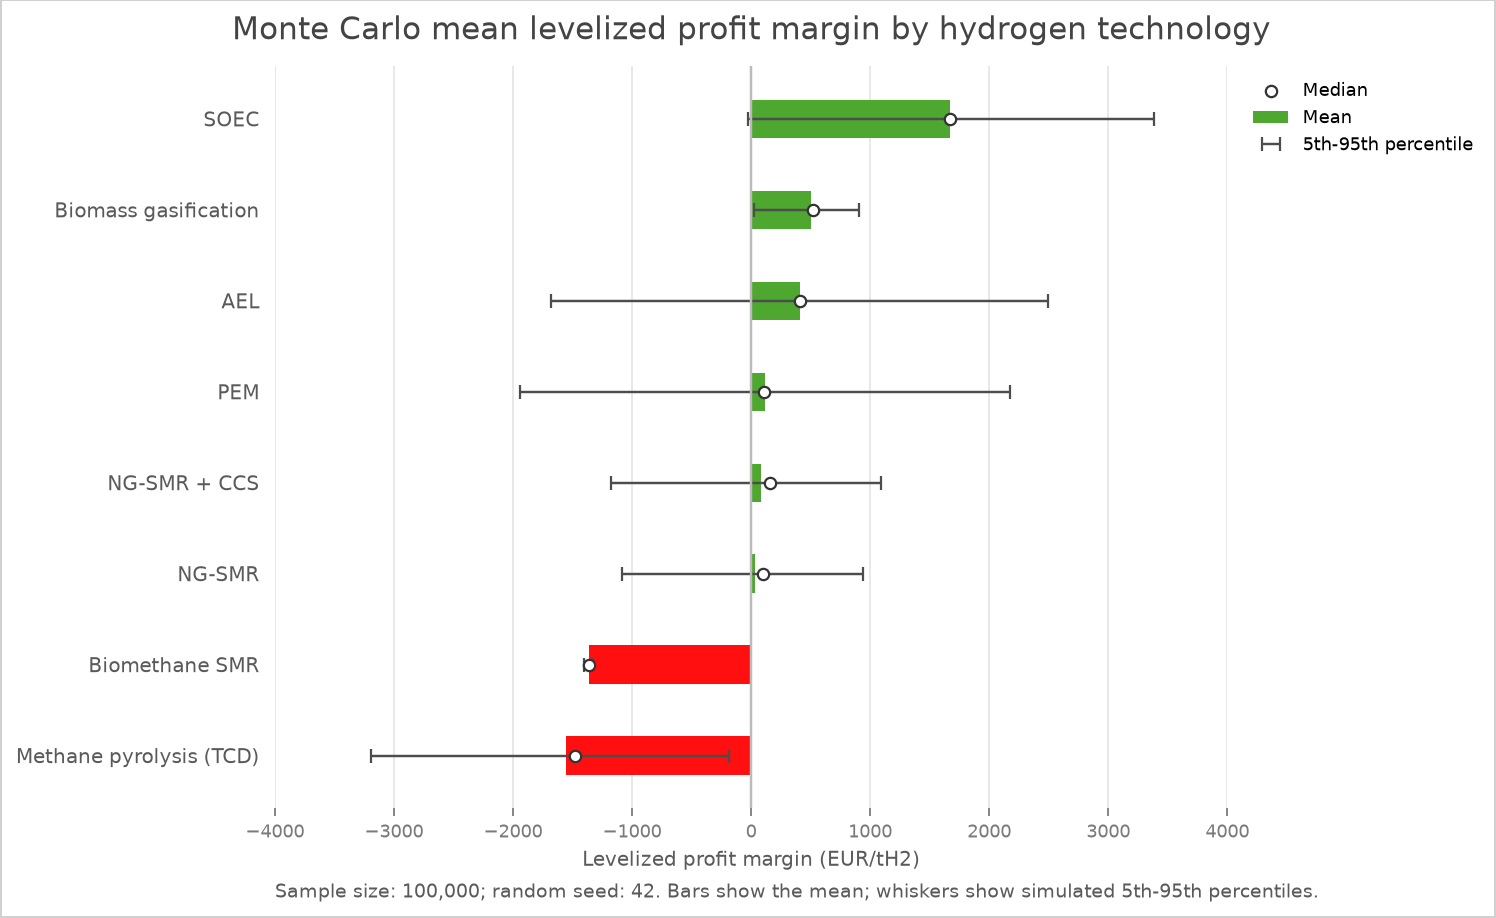

In [3]:
monte_carlo_results = simulate_hydrogen_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=TECHNOLOGIES,
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)

mc_summary_rows = []
for technology, results in monte_carlo_results.items():
    values = np.asarray(results[METRIC_COLUMN], dtype=float) / METRIC_SCALE_FACTOR
    mc_summary_rows.append(
        {
            "label": HYDROGEN_TECHNOLOGY_LABELS.get(technology, technology),
            "technology_type": str(np.asarray(results["technology_type"])[0]),
            METRIC_SUMMARY_COLUMN: values.mean(),
            "median": np.median(values),
            "p05": np.percentile(values, 5),
            "p95": np.percentile(values, 95),
            **summarize_metric_signs(values),
        }
    )
mc_summary = pd.DataFrame(mc_summary_rows).sort_values(
    METRIC_SUMMARY_COLUMN, ascending=not METRIC_HIGHER_IS_BETTER
)
mc_summary_by_label = mc_summary.set_index("label")

deterministic_results = calculate_deterministic_hydrogen_results(technologies=TECHNOLOGIES)
det_summary_rows = []
for technology, results in deterministic_results.items():
    det_summary_rows.append(
        {
            "label": HYDROGEN_TECHNOLOGY_LABELS.get(technology, technology),
            "technology_type": str(np.asarray(results["technology_type"])[0]),
            METRIC_SUMMARY_COLUMN: (
                float(np.asarray(results[METRIC_COLUMN]).item()) / METRIC_SCALE_FACTOR
            ),
        }
    )
det_summary = pd.DataFrame(det_summary_rows).sort_values(
    METRIC_SUMMARY_COLUMN, ascending=not METRIC_HIGHER_IS_BETTER
)
det_summary_by_label = det_summary.set_index("label")

BAR_X_AXIS_LIMITS, BAR_X_AXIS_TICKS = shared_financial_metric_bar_axis_config(
    distribution_summary=mc_summary_by_label[["p05", "p95"]].to_dict(orient="index"),
    deterministic_values=det_summary_by_label[METRIC_SUMMARY_COLUMN].to_dict(),
    zero_floor=METRIC_ZERO_BASELINE,
    tick_step=METRIC_AXIS_TICK_STEP,
)

display(mc_summary)
plot_financial_metric_technology_bars(
    values=mc_summary_by_label[METRIC_SUMMARY_COLUMN].to_dict(),
    output_path=None,
    title=f"Monte Carlo mean {METRIC_RANKING_LABEL} by hydrogen technology",
    median_values=mc_summary_by_label["median"].to_dict(),
    lower_values=mc_summary_by_label["p05"].to_dict(),
    upper_values=mc_summary_by_label["p95"].to_dict(),
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    x_axis_label=METRIC_AXIS_LABEL,
    higher_is_better=METRIC_HIGHER_IS_BETTER,
    color_by_sign=METRIC_COLOR_BY_SIGN,
    zero_baseline=METRIC_ZERO_BASELINE,
    x_axis_limits=BAR_X_AXIS_LIMITS,
    x_axis_ticks=BAR_X_AXIS_TICKS,
)
plt.show()


## Deterministic financial metric

,label,technology_type,levelized_profit_margin_eur_per_th2
3,SOEC,absolute,"1,673.835"
5,Biomass gasification,absolute,497.776
1,AEL,absolute,408.283
2,PEM,absolute,114.193
7,NG-SMR + CCS,retrofit,77.849
0,NG-SMR,absolute,29.848
6,Biomethane SMR,retrofit,"-1,365.650"
4,Methane pyrolysis (TCD),absolute,"-1,559.724"


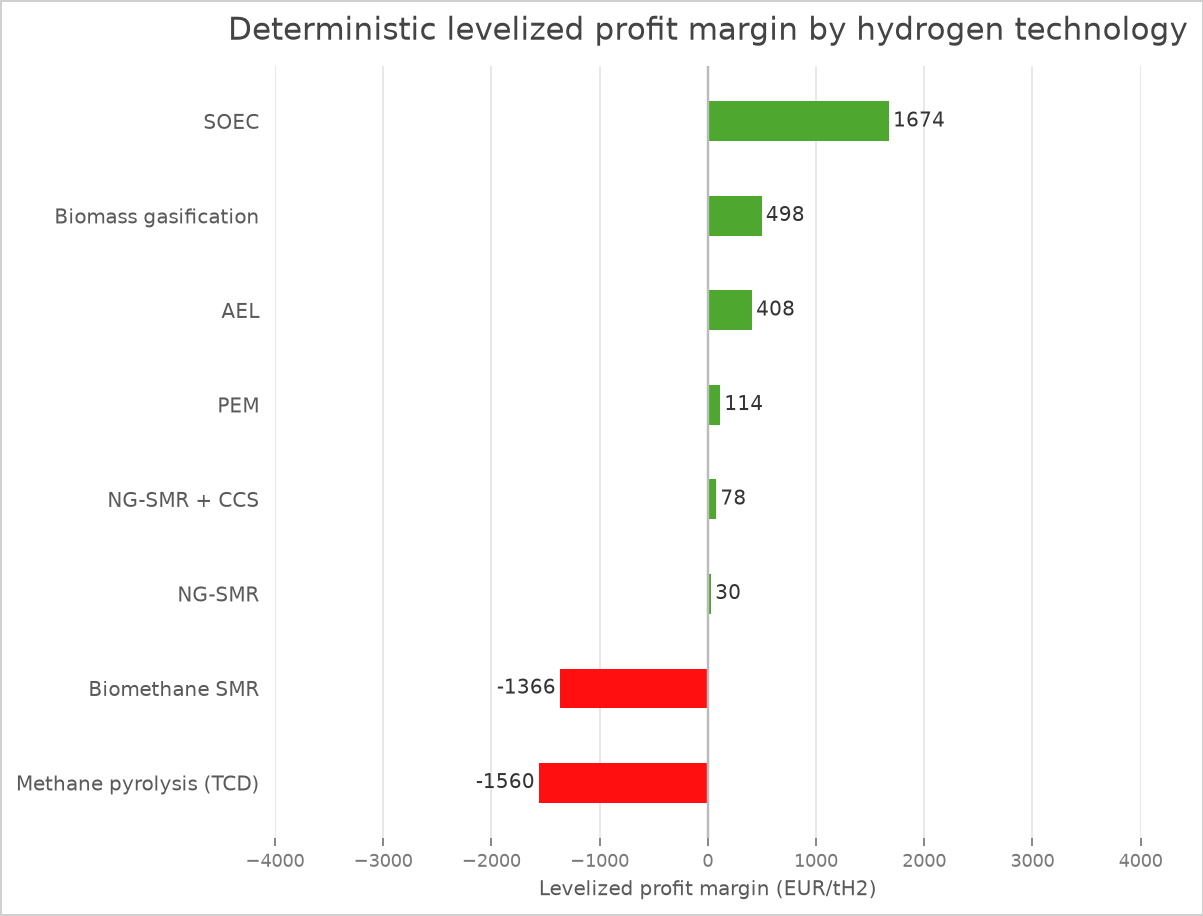

In [4]:
display(det_summary)
plot_financial_metric_technology_bars(
    values=det_summary_by_label[METRIC_SUMMARY_COLUMN].to_dict(),
    output_path=None,
    title=f"Deterministic {METRIC_RANKING_LABEL} by hydrogen technology",
    x_axis_label=METRIC_AXIS_LABEL,
    higher_is_better=METRIC_HIGHER_IS_BETTER,
    color_by_sign=METRIC_COLOR_BY_SIGN,
    zero_baseline=METRIC_ZERO_BASELINE,
    x_axis_limits=BAR_X_AXIS_LIMITS,
    x_axis_ticks=BAR_X_AXIS_TICKS,
)
plt.show()


## Monte Carlo financial-metric ranking

,Technology,Average rank,Probability rank 1,Probability top 3,Simulations
0,SOEC,1.352,0.817,0.929,100000
1,Biomass gasification,3.310,0.112,0.477,100000
2,AEL,3.602,0.000,0.572,100000
3,NG-SMR + CCS,3.962,0.070,0.357,100000
4,NG-SMR,4.495,0.001,0.285,100000
5,PEM,4.741,0.000,0.377,100000
6,Biomethane SMR,7.175,0.000,0.002,100000
7,Methane pyrolysis (TCD),7.363,0.000,0.000,100000


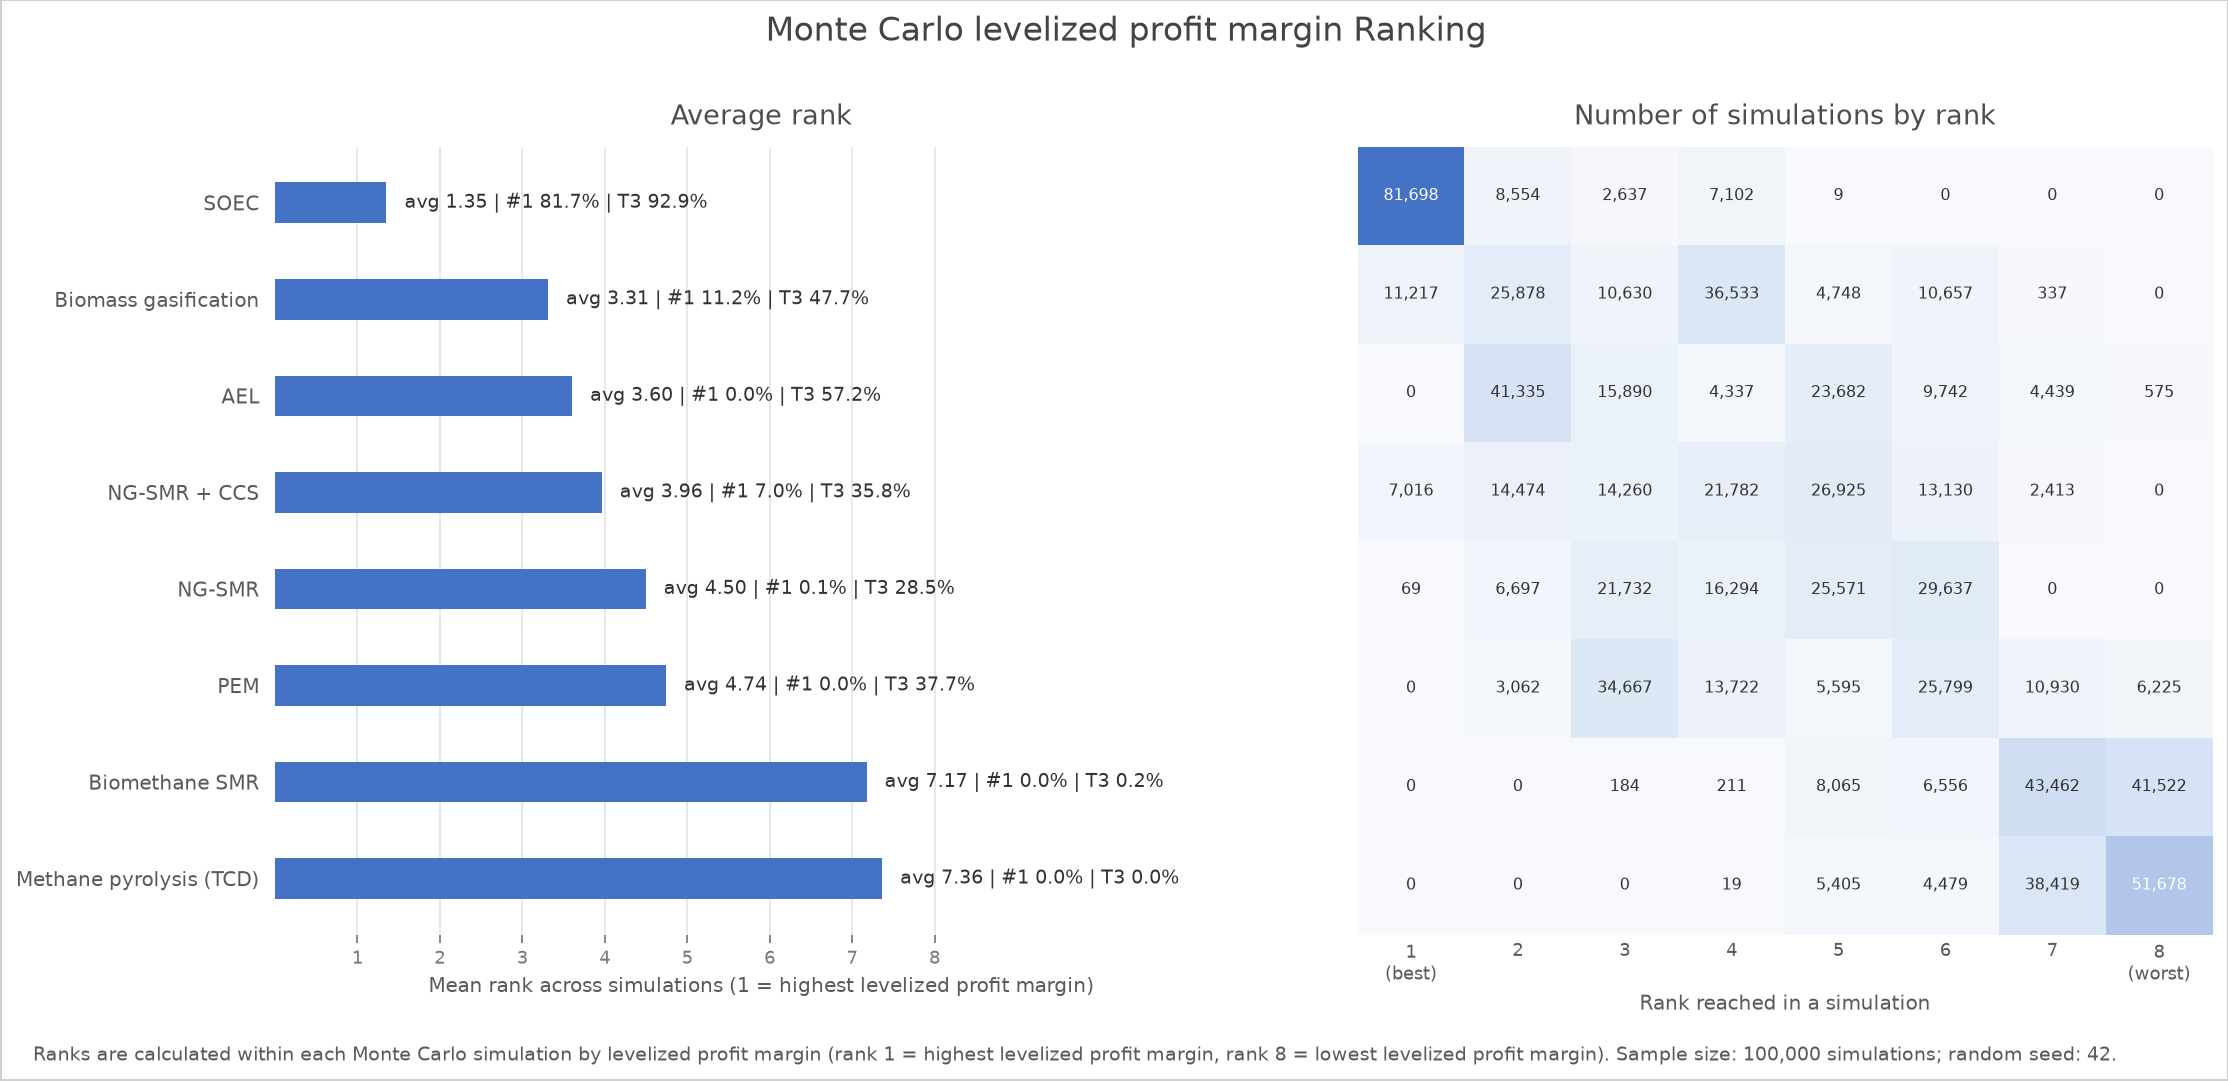

In [5]:
ranking_raw, ranking_summary = calculate_hydrogen_npv_rankings_from_results(
    results=monte_carlo_results,
    sector_name="Hydrogen",
    financial_metric=FINANCIAL_METRIC,
)

ranking_summary_for_plot = ranking_summary.assign(
    display_label=ranking_summary["technology"].map(HYDROGEN_TECHNOLOGY_LABELS).fillna(ranking_summary["technology"])
)
rank_table = (
    ranking_summary_for_plot.rename(columns={"display_label": "Technology"})
    .loc[:, ["Technology", "average_rank", "probability_rank_1", "probability_top_3", "n_simulations"]]
    .rename(
        columns={
            "average_rank": "Average rank",
            "probability_rank_1": "Probability rank 1",
            "probability_top_3": "Probability top 3",
            "n_simulations": "Simulations",
        }
    )
)
display(rank_table)
plot_average_rank_bars(
    ranking_summary=ranking_summary_for_plot,
    output_path=None,
    title=f"Monte Carlo {METRIC_RANKING_LABEL} Ranking",
    metric_label=METRIC_RANKING_LABEL,
    random_seed=RANDOM_SEED,
    higher_is_better=METRIC_HIGHER_IS_BETTER,
)
plt.show()
